times           = [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35] ...
tls_pop         = [0.9508278  0.9040735  0.85961822 0.81734889 0.77715805 0.73894348
 0.702608   0.66805922] ...
flux_left       = [0.5        0.24369855 0.15833709 0.11571055 0.09017792 0.07319214
 0.06109021 0.05204058] ...
flux_right      = [0.5        0.24369855 0.15833709 0.11571055 0.09017792 0.07319214
 0.06109021 0.05204058] ...
total_quanta    = [1.0008278  0.97844336 0.94982178 0.91912351 0.88795046 0.8570551
 0.82682864 0.79748392] ...


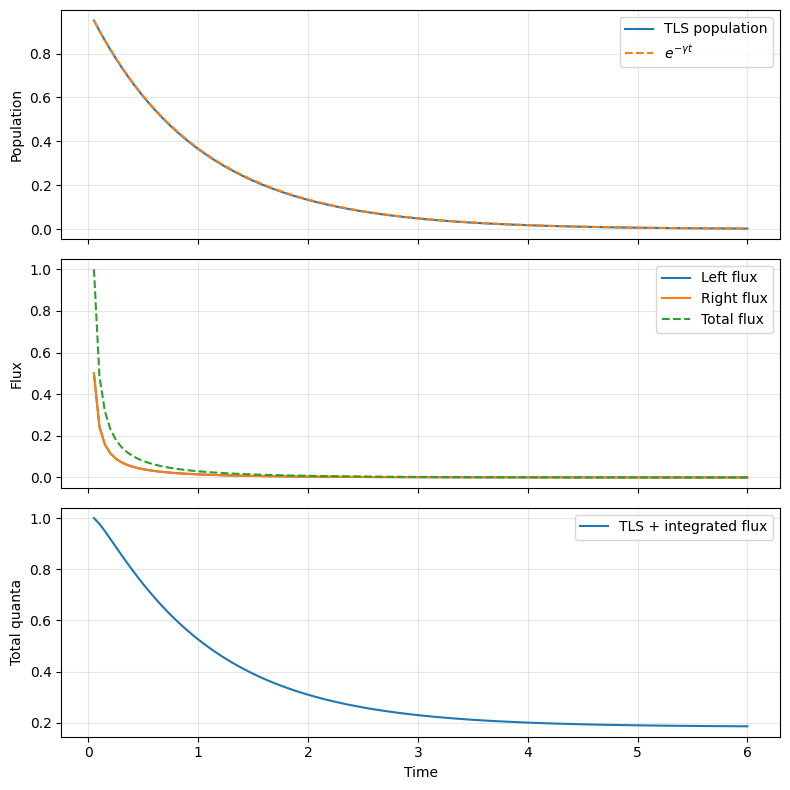

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable

import copy
import numpy as np
import matplotlib.pyplot as plt


from seemps.state import CanonicalMPS, product_state, DEFAULT_STRATEGY

import wqedlib as qmps


Hamiltonian = np.ndarray | Callable[[int], np.ndarray]


# ============================================================
# Parameter helper
# ============================================================


def build_default_input_params(
    delta_t: float = 0.05,
    tmax: float = 6.0,
    bond_max: int = 32,
    d_t_l: int = 2,
    d_t_r: int = 2,
    coupling_mode: str = "symmetrical",
    gamma: float = 1.0,
):
    gamma_l, gamma_r = qmps.coupling(coupling_mode, gamma=gamma)
    return qmps.parameters.InputParams(
        delta_t=delta_t,
        tmax=tmax,
        d_sys_total=np.array([2], dtype=int),
        d_t_total=np.array([d_t_l, d_t_r], dtype=int),
        gamma_l=gamma_l,
        gamma_r=gamma_r,
        bond_max=bond_max,
    )


# ============================================================
# Standard observable helper
# ============================================================


def compute_standard_observables(bins: BinsSeemps, params):
    """
    Mimic the usual Qwave/wqedlib workflow.
    """
    tls_pop_op = qmps.tls_pop()
    b_pop_l = qmps.num_op_l(params.d_t_total)
    b_pop_r = qmps.num_op_r(params.d_t_total)

    tls_pop = qmps.single_time_expectation(bins.system_states, tls_pop_op)
    photon_fluxes = qmps.single_time_expectation(
        bins.output_field_states, [b_pop_l, b_pop_r]
    )

    net_flux_l = np.cumsum(photon_fluxes[0]) * params.delta_t
    net_flux_r = np.cumsum(photon_fluxes[1]) * params.delta_t
    total_quanta = tls_pop + net_flux_l + net_flux_r

    return {
        "tls_pop": np.asarray(tls_pop, float),
        "photon_flux_l": np.asarray(photon_fluxes[0], float),
        "photon_flux_r": np.asarray(photon_fluxes[1], float),
        "net_flux_l": np.asarray(net_flux_l, float),
        "net_flux_r": np.asarray(net_flux_r, float),
        "total_quanta": np.asarray(total_quanta, float),
    }


# ============================================================
# Plot helper
# ============================================================


def plot_standard_observables(bins: BinsSeemps, params):
    obs = compute_standard_observables(bins, params)
    t = bins.times[1:]
    gamma_total = params.gamma_l + params.gamma_r

    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

    axes[0].plot(t, obs["tls_pop"], label="TLS population")
    axes[0].plot(t, np.exp(-gamma_total * t), "--", label=rf"$e^{{-\gamma t}}$")
    axes[0].set_ylabel("Population")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, obs["photon_flux_l"], label="Left flux")
    axes[1].plot(t, obs["photon_flux_r"], label="Right flux")
    axes[1].plot(
        t, obs["photon_flux_l"] + obs["photon_flux_r"], "--", label="Total flux"
    )
    axes[1].set_ylabel("Flux")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, obs["total_quanta"], label="TLS + integrated flux")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Total quanta")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# Example
# ============================================================

if __name__ == "__main__":
    params = build_default_input_params(
        delta_t=0.05,
        tmax=6.0,
        bond_max=32,
        d_t_l=2,
        d_t_r=2,
        coupling_mode="symmetrical",
        gamma=1.0,
    )

    # local initial states only
    i_s0 = qmps.tls_excited()
    i_n0 = qmps.wg_ground(int(np.prod(params.d_t_total)))

    # local collision Hamiltonian from your library
    hm = qmps.atom_waveguide_markov_hamiltonian_lr(params)

    # evolve -> only bins
    bins = qmps.t_evol_mar_seemps_lr(hm, i_s0, i_n0, params, store_mps=True)

    # choose observables later, exactly Qwave style
    tls_pop_op = qmps.tls_pop()
    b_pop_l = qmps.num_op_l(params.d_t_total)
    b_pop_r = qmps.num_op_r(params.d_t_total)

    tls_pop = qmps.single_time_expectation(bins.system_states, tls_pop_op)
    photon_fluxes = qmps.single_time_expectation(
        bins.output_field_states, [b_pop_l, b_pop_r]
    )

    net_flux_l = np.cumsum(photon_fluxes[0]) * params.delta_t
    net_flux_r = np.cumsum(photon_fluxes[1]) * params.delta_t
    total_quanta = tls_pop + net_flux_l + net_flux_r

    print("times           =", bins.times[:8], "...")
    print("tls_pop         =", tls_pop[:8], "...")
    print("flux_left       =", photon_fluxes[0][:8], "...")
    print("flux_right      =", photon_fluxes[1][:8], "...")
    print("total_quanta    =", total_quanta[:8], "...")

    plot_standard_observables(bins, params)

times           = [0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14] ...
P_e(t)          = [1.         0.98013298 0.96066066 0.94157519 0.92286889 0.90453424
 0.88656384 0.86895045] ...
n_left(bin)     = [0.         0.00993351 0.00973616 0.00954273 0.00935315 0.00916733
 0.0089852  0.00880669] ...
n_right(bin)    = [0.         0.00993351 0.00973616 0.00954273 0.00935315 0.00916733
 0.0089852  0.00880669] ...
n_total(bin)    = [0.         0.01986702 0.01947232 0.01908547 0.01870629 0.01833466
 0.0179704  0.01761338] ...


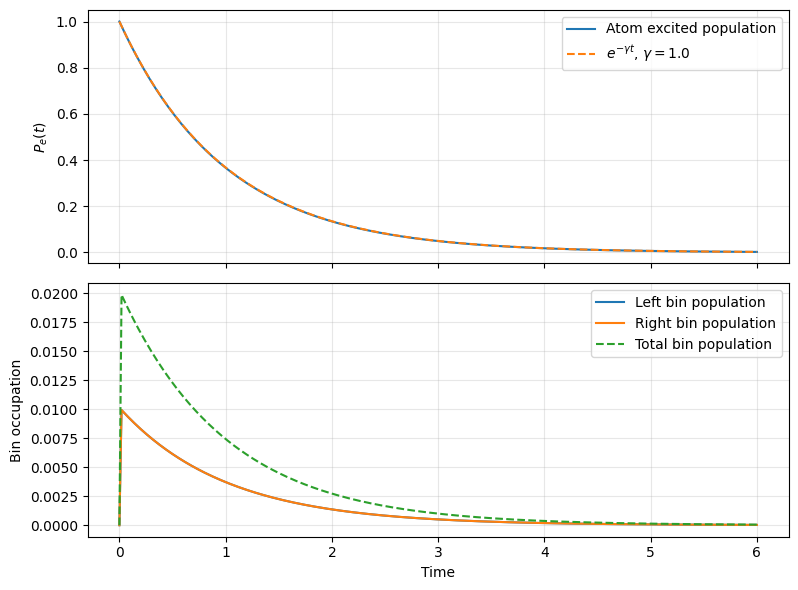

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from seemps.state import CanonicalMPS, product_state, DEFAULT_STRATEGY
from seemps.expectation import expectation1


# ============================================================
# Dataclasses
# ============================================================

Hamiltonian = np.ndarray | Callable[[int], np.ndarray]


@dataclass
class InputParams:
    delta_t: float
    tmax: float
    bond_max: int = 32
    d_sys_total: tuple[int, ...] = (2,)
    d_t_total: tuple[int, ...] = (2, 2)  # (left, right)
    gamma_L: float = 0.5
    gamma_R: float = 0.5
    delta: float = 0.0
    omega: float = 0.0
    atol: float = 1e-12


@dataclass
class BinsSeemps:
    psi_final: CanonicalMPS
    times: np.ndarray
    p_atom_excited: np.ndarray
    n_left_bins: np.ndarray
    n_right_bins: np.ndarray
    schmidt: list[np.ndarray]


# ============================================================
# Atomic operators
# Basis:
#   atom : |g> = [1,0], |e> = [0,1]
# ============================================================


def sigma_minus() -> np.ndarray:
    return np.array([[0.0, 1.0], [0.0, 0.0]], dtype=complex)


def sigma_plus() -> np.ndarray:
    return sigma_minus().conj().T


def proj_excited() -> np.ndarray:
    return np.array([[0.0, 0.0], [0.0, 1.0]], dtype=complex)


# ============================================================
# Two-mode bin operators
#
# bin basis = |nL, nR>
#   0 -> |0,0>
#   1 -> |1,0>
#   2 -> |0,1>
#   3 -> |1,1>
#
# This is two qubits packed into one 4D local site.
# ============================================================


def a_qubit() -> np.ndarray:
    return np.array([[0.0, 1.0], [0.0, 0.0]], dtype=complex)


def n_qubit() -> np.ndarray:
    return np.array([[0.0, 0.0], [0.0, 1.0]], dtype=complex)


def two_mode_bin_ops():
    a = a_qubit()
    adag = a.conj().T
    n = n_qubit()
    I = np.eye(2, dtype=complex)

    aL = np.kron(a, I)
    aR = np.kron(I, a)
    adagL = aL.conj().T
    adagR = aR.conj().T
    nL = np.kron(n, I)
    nR = np.kron(I, n)

    return aL, adagL, aR, adagR, nL, nR


# ============================================================
# Local Hamiltonian for atom + one bidirectional time bin
# ============================================================


def atom_waveguide_markov_hamiltonian_lr(
    delta_t: float,
    gamma_L: float = 0.5,
    gamma_R: float = 0.5,
    delta: float = 0.0,
    omega: float = 0.0,
) -> np.ndarray:
    r"""
    One collision Hamiltonian for:
        atom (2D) + one time bin with left/right modes (4D)

    H = H_atom
        + i * sqrt(gamma_L/dt) * (aL^\dag sigma- - aL sigma+)
        + i * sqrt(gamma_R/dt) * (aR^\dag sigma- - aR sigma+)

    Returned shape: (2*4, 2*4) = (8, 8)
    """
    sm = sigma_minus()
    sp = sigma_plus()
    pe = proj_excited()

    aL, adagL, aR, adagR, _, _ = two_mode_bin_ops()
    Ibin = np.eye(4, dtype=complex)

    H_atom = delta * pe + 0.5 * omega * (sp + sm)

    H_int_L = 1j * np.sqrt(gamma_L / delta_t) * (np.kron(sm, adagL) - np.kron(sp, aL))
    H_int_R = 1j * np.sqrt(gamma_R / delta_t) * (np.kron(sm, adagR) - np.kron(sp, aR))

    H = np.kron(H_atom, Ibin) + H_int_L + H_int_R
    return H


def local_gate_from_hamiltonian(
    H: np.ndarray, delta_t: float, d_sys: int, d_t: int
) -> np.ndarray:
    """
    U[s'_sys, s'_bin, s_sys, s_bin]
    """
    U = expm(-1j * H * delta_t)
    return U.reshape(d_sys, d_t, d_sys, d_t)


def swap_gate(d1: int, d2: int) -> np.ndarray:
    """
    Rank-4 swap gate:
        S[j, i, i, j] = 1
    output indices first, input indices last
    """
    S = np.zeros((d2, d1, d1, d2), dtype=complex)
    for i in range(d1):
        for j in range(d2):
            S[j, i, i, j] = 1.0
    return S


# ============================================================
# MPS helpers
# ============================================================


def _try_replace_bond_limit(strategy, bond_max: int):
    for key in ("max_bond_dimension", "max_bond", "chi_max", "bond_max"):
        try:
            return strategy.replace(**{key: bond_max})
        except Exception:
            pass
    return strategy


def make_product_mps(
    i_s0_vec: np.ndarray,
    i_n0_vec: np.ndarray,
    n_steps: int,
) -> CanonicalMPS:
    """
    Chain order:
        [system, bin0, bin1, ..., bin_{n_steps-1}]
    """
    sites = [np.asarray(i_s0_vec, complex)]
    for _ in range(n_steps):
        sites.append(np.asarray(i_n0_vec, complex))

    psi0 = product_state(sites)
    return CanonicalMPS(psi0, center=0, normalize=True)


def merge_two_sites(psi: CanonicalMPS, site: int) -> np.ndarray:
    """
    AA[a, i, j, b]
    """
    A = psi[site]
    B = psi[site + 1]
    return np.tensordot(A, B, axes=(2, 0))


def apply_two_site_gate(AA: np.ndarray, U4: np.ndarray) -> np.ndarray:
    """
    U4[p, q, i, j], AA[a, i, j, b] -> AA'[a, p, q, b]
    """
    return np.einsum("pqij,aijb->apqb", U4, AA, optimize=True)


def schmidt_values_from_theta(
    AA: np.ndarray, bond_max: int | None = None
) -> np.ndarray:
    chiL, d1, d2, chiR = AA.shape
    M = AA.reshape(chiL * d1, d2 * chiR)
    s = np.linalg.svd(M, compute_uv=False)
    if bond_max is not None:
        s = s[:bond_max]
    return s


# ============================================================
# Main evolution
# ============================================================


def t_evol_mar_seemps_lr(
    ham: Hamiltonian,
    i_s0: np.ndarray,
    i_n0: np.ndarray,
    params: InputParams,
) -> BinsSeemps:
    """
    Markovian time-bin evolution with left/right bin modes packed
    into one 4D bin site.
    """
    delta_t = params.delta_t
    tmax = params.tmax
    d_t = int(np.prod(params.d_t_total))  # 2*2 = 4
    d_sys = int(np.prod(params.d_sys_total))  # 2
    n_steps = int(round(tmax / delta_t))

    if d_sys != len(i_s0):
        raise ValueError(f"d_sys={d_sys}, but len(i_s0)={len(i_s0)}")
    if d_t != len(i_n0):
        raise ValueError(f"d_t={d_t}, but len(i_n0)={len(i_n0)}")
    if d_sys != 2 or d_t != 4:
        raise NotImplementedError(
            "This version assumes atom qubit + 4D left/right bin."
        )

    psi = make_product_mps(i_s0, i_n0, n_steps)

    strategy = DEFAULT_STRATEGY.replace(tolerance=params.atol)
    strategy = _try_replace_bond_limit(strategy, params.bond_max)

    P_e = proj_excited()
    _, _, _, _, N_L, N_R = two_mode_bin_ops()
    SWAP4 = swap_gate(d_sys, d_t)

    times = np.arange(n_steps + 1) * delta_t
    p_atom_excited = np.zeros(n_steps + 1, dtype=float)
    n_left_bins = np.zeros(n_steps + 1, dtype=float)
    n_right_bins = np.zeros(n_steps + 1, dtype=float)
    schmidt_list: list[np.ndarray] = [np.array([1.0])]

    p_atom_excited[0] = float(np.real(expectation1(psi, P_e, 0)))

    for k in range(n_steps):
        atom_site = k
        bin_site = k + 1

        Hk = ham(k) if callable(ham) else ham
        U4 = local_gate_from_hamiltonian(Hk, delta_t, d_sys, d_t)

        # 1) local atom-bin evolution
        AA = merge_two_sites(psi, atom_site)
        AA = apply_two_site_gate(AA, U4)

        svals = schmidt_values_from_theta(AA, bond_max=params.bond_max)
        schmidt_list.append(svals)

        psi.update_2site_right(AA, atom_site, strategy)

        # 2) swap, move atom one site to the right
        AA = merge_two_sites(psi, atom_site)
        AA = apply_two_site_gate(AA, SWAP4)
        psi.update_2site_right(AA, atom_site, strategy)

        # after swap:
        #   site k   = output bin
        #   site k+1 = atom
        p_atom_excited[k + 1] = float(np.real(expectation1(psi, P_e, atom_site + 1)))
        n_left_bins[k + 1] = float(np.real(expectation1(psi, N_L, atom_site)))
        n_right_bins[k + 1] = float(np.real(expectation1(psi, N_R, atom_site)))

    return BinsSeemps(
        psi_final=psi,
        times=times,
        p_atom_excited=p_atom_excited,
        n_left_bins=n_left_bins,
        n_right_bins=n_right_bins,
        schmidt=schmidt_list,
    )


# ============================================================
# Plot
# ============================================================


def plot_dynamics(res: BinsSeemps, gamma_total: float | None = None):
    t = res.times
    pe = res.p_atom_excited
    nL = res.n_left_bins
    nR = res.n_right_bins

    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # atom dynamics
    axes[0].plot(t, pe, label="Atom excited population")
    if gamma_total is not None:
        axes[0].plot(
            t,
            np.exp(-gamma_total * t),
            "--",
            label=rf"$e^{{-\gamma t}}$, $\gamma={gamma_total}$",
        )
    axes[0].set_ylabel(r"$P_e(t)$")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # emitted bin populations
    axes[1].plot(t, nL, label="Left bin population")
    axes[1].plot(t, nR, label="Right bin population")
    axes[1].plot(t, nL + nR, "--", label="Total bin population")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Bin occupation")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# Example
# ============================================================

if __name__ == "__main__":
    params = InputParams(
        delta_t=0.02,
        tmax=6.0,
        bond_max=16,
        gamma_L=0.5,
        gamma_R=0.5,
        delta=0.0,
        omega=0.0,
    )

    # atom initially excited
    i_s0 = np.array([0.0, 1.0], dtype=complex)  # |e>

    # vacuum bin: |0L,0R> = |00>
    i_n0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)

    Hloc = atom_waveguide_markov_hamiltonian_lr(
        delta_t=params.delta_t,
        gamma_L=params.gamma_L,
        gamma_R=params.gamma_R,
        delta=params.delta,
        omega=params.omega,
    )

    res = t_evol_mar_seemps_lr(Hloc, i_s0, i_n0, params)

    gamma_total = params.gamma_L + params.gamma_R

    print("times           =", res.times[:8], "...")
    print("P_e(t)          =", res.p_atom_excited[:8], "...")
    print("n_left(bin)     =", res.n_left_bins[:8], "...")
    print("n_right(bin)    =", res.n_right_bins[:8], "...")
    print("n_total(bin)    =", (res.n_left_bins + res.n_right_bins)[:8], "...")

    plot_dynamics(res, gamma_total=gamma_total)